# 🌟 Grafos Especiais

**Conteúdo:** Grafos bipartidos, multigrafos, hipergrafos, grafos valorados, grafos planares e subgrafos.

---

In [10]:
# Importando bibliotecas
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
%matplotlib inline

## 1. Grafo Bipartido

### 📚 Definição:

Um **grafo bipartido** é um grafo cujos vértices podem ser divididos em **dois conjuntos disjuntos** $V_1$ e $V_2$, tal que:

1. $\forall$ arestas conectam algum vértice de $V_1$ a algum vértice de $V_2$
2. $\nexists$ aresta entre dois vértices de $V_1$
3. $\nexists$ aresta entre dois vértices de $V_2$

**Exemplo:** Relacionamento entre estudantes e cursos, autores e artigos, etc.

O grafo é bipartido? True



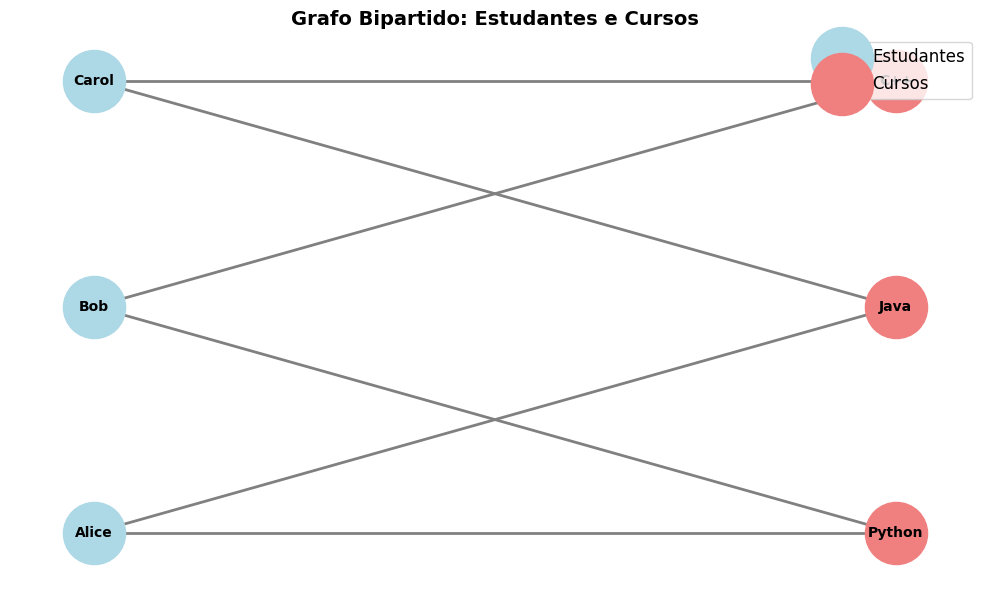

Conjunto 1 (Estudantes): ['Alice', 'Bob', 'Carol']
Conjunto 2 (Cursos): ['Python', 'Java', 'C++']
Arestas: [('Alice', 'Python'), ('Alice', 'Java'), ('Bob', 'Python'), ('Bob', 'C++'), ('Carol', 'Java'), ('Carol', 'C++')]


In [11]:
# Criando um grafo bipartido
# Conjunto 1: Estudantes
# Conjunto 2: Cursos

B = nx.Graph()

# Adicionando vértices dos dois conjuntos
estudantes = ['Alice', 'Bob', 'Carol']
cursos = ['Python', 'Java', 'C++']

B.add_nodes_from(estudantes, bipartite=0)  # Conjunto 0
B.add_nodes_from(cursos, bipartite=1)      # Conjunto 1

# Adicionando arestas (estudante -> curso)
B.add_edges_from([
    ('Alice', 'Python'),
    ('Alice', 'Java'),
    ('Bob', 'Python'),
    ('Bob', 'C++'),
    ('Carol', 'Java'),
    ('Carol', 'C++')
])

# Verificando se é bipartido
eh_bipartido = nx.is_bipartite(B)
print(f"O grafo é bipartido? {eh_bipartido}\n")

# Layout bipartido
pos = {}
for i, est in enumerate(estudantes):
    pos[est] = (0, i)
for i, cur in enumerate(cursos):
    pos[cur] = (2, i)

plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(B, pos, nodelist=estudantes, 
                       node_color='lightblue', node_size=2000, label='Estudantes')
nx.draw_networkx_nodes(B, pos, nodelist=cursos, 
                       node_color='lightcoral', node_size=2000, label='Cursos')
nx.draw_networkx_labels(B, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(B, pos, edge_color='gray', width=2)

plt.title('Grafo Bipartido: Estudantes e Cursos', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Conjunto 1 (Estudantes): {estudantes}")
print(f"Conjunto 2 (Cursos): {cursos}")
print(f"Arestas: {list(B.edges())}")

---

## 2. Grafo Bipartido Completo ($K_{m,n}$)

### 📚 Definição:

Um **grafo bipartido completo** $K_{m,n}$ é um grafo bipartido onde:
- Existem $m$ vértices no primeiro conjunto
- Existem $n$ vértices no segundo conjunto
- **Existe uma aresta entre cada par de vértices** de conjuntos diferentes
- Total de arestas: $m \times n$

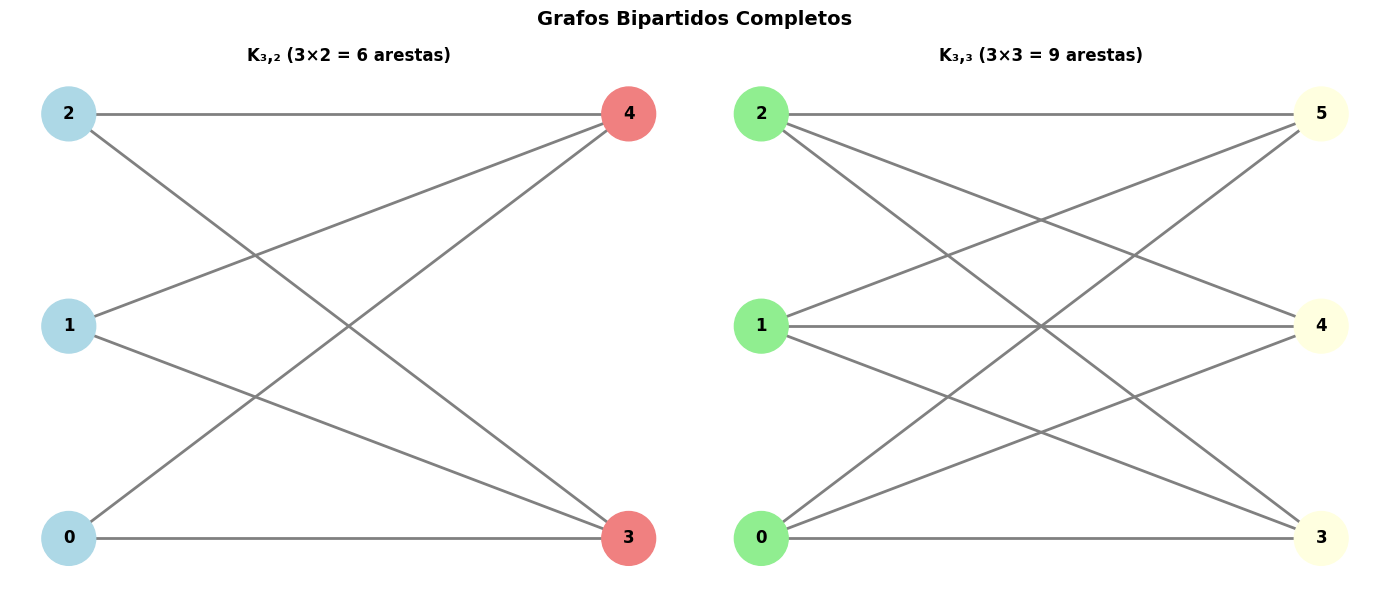

K₃,₂: 5 vértices, 6 arestas
K₃,₃: 6 vértices, 9 arestas


In [12]:
# Gerando grafos bipartidos completos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K_{3,2}
K_32 = nx.complete_bipartite_graph(3, 2)
pos1 = nx.bipartite_layout(K_32, [0, 1, 2])
nx.draw(K_32, pos1, ax=axes[0],
        with_labels=True,
        node_color=['lightblue']*3 + ['lightcoral']*2,
        node_size=1500,
        font_size=12,
        font_weight='bold',
        edge_color='gray',
        width=2)
axes[0].set_title('K₃,₂ (3×2 = 6 arestas)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# K_{3,3}
K_33 = nx.complete_bipartite_graph(3, 3)
pos2 = nx.bipartite_layout(K_33, [0, 1, 2])
nx.draw(K_33, pos2, ax=axes[1],
        with_labels=True,
        node_color=['lightgreen']*3 + ['lightyellow']*3,
        node_size=1500,
        font_size=12,
        font_weight='bold',
        edge_color='gray',
        width=2)
axes[1].set_title('K₃,₃ (3×3 = 9 arestas)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Grafos Bipartidos Completos', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"K₃,₂: {K_32.number_of_nodes()} vértices, {K_32.number_of_edges()} arestas")
print(f"K₃,₃: {K_33.number_of_nodes()} vértices, {K_33.number_of_edges()} arestas")

---

## 3. Multigrafo

### 📚 Definição:

Um **multigrafo** é um grafo que:
- **Não possui laços**
- **Pode ter arestas paralelas** (múltiplas arestas entre o mesmo par de vértices)

**Aplicação:** Modelar rotas de transporte com múltiplas linhas entre cidades, redes com múltiplas conexões, etc.

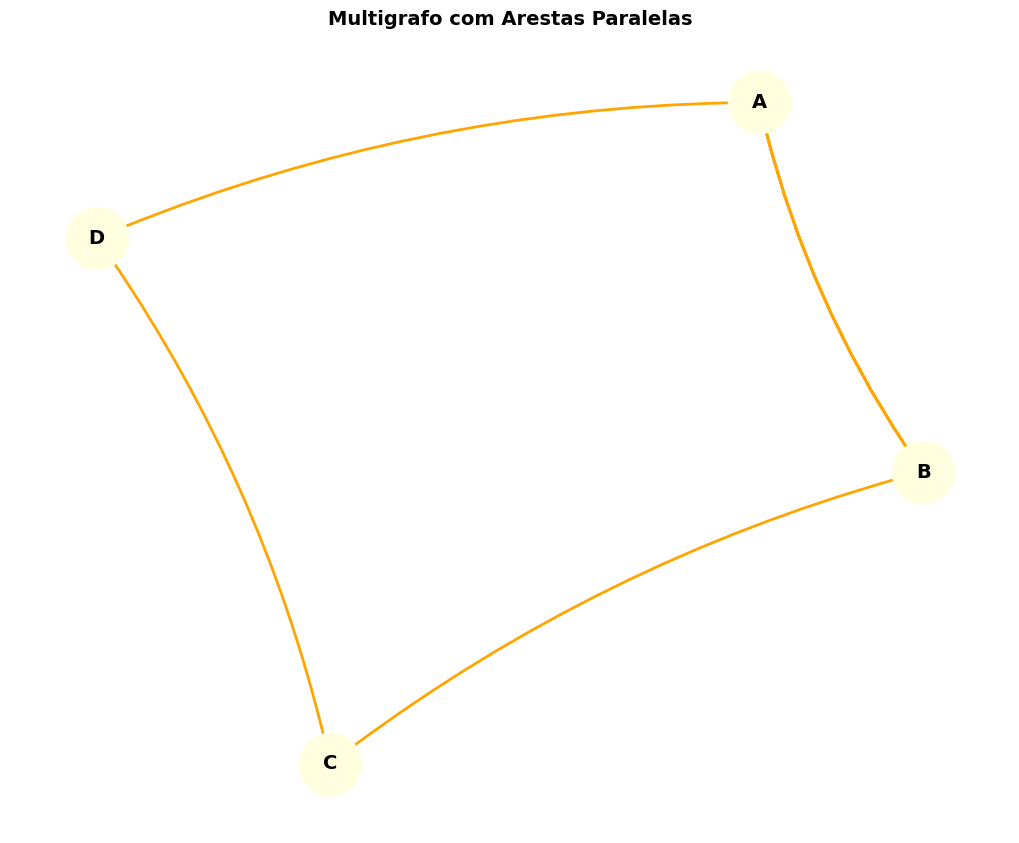

Vértices: ['A', 'B', 'C', 'D']
Número de arestas (incluindo paralelas): 6

Arestas entre A e B: 3

Note: A-B tem 3 arestas paralelas (Rotas 1, 2 e 3)


In [13]:
# Criando um multigrafo
M = nx.MultiGraph()

# Adicionando vértices
M.add_nodes_from(['A', 'B', 'C', 'D'])

# Adicionando arestas (incluindo paralelas)
M.add_edge('A', 'B', label='Rota 1')
M.add_edge('A', 'B', label='Rota 2')  # Aresta paralela
M.add_edge('A', 'B', label='Rota 3')  # Outra aresta paralela
M.add_edge('B', 'C', label='Rota 4')
M.add_edge('C', 'D', label='Rota 5')
M.add_edge('D', 'A', label='Rota 6')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(M, seed=42)
nx.draw(M, pos,
        with_labels=True,
        node_color='lightyellow',
        node_size=2000,
        font_size=14,
        font_weight='bold',
        edge_color='orange',
        width=2,
        connectionstyle='arc3,rad=0.1')
plt.title('Multigrafo com Arestas Paralelas', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Vértices: {list(M.nodes())}")
print(f"Número de arestas (incluindo paralelas): {M.number_of_edges()}")
print(f"\nArestas entre A e B: {M.number_of_edges('A', 'B')}")
print("\nNote: A-B tem 3 arestas paralelas (Rotas 1, 2 e 3)")

---

## 4. Grafo Valorizado (Ponderado)

### 📚 Definição:

Um **grafo valorizado** (ou **ponderado**) é um grafo onde **cada aresta tem um valor (peso) associado**.

**Aplicações:**
- Distâncias entre cidades
- Custos de transporte
- Tempos de viagem
- Capacidades de redes

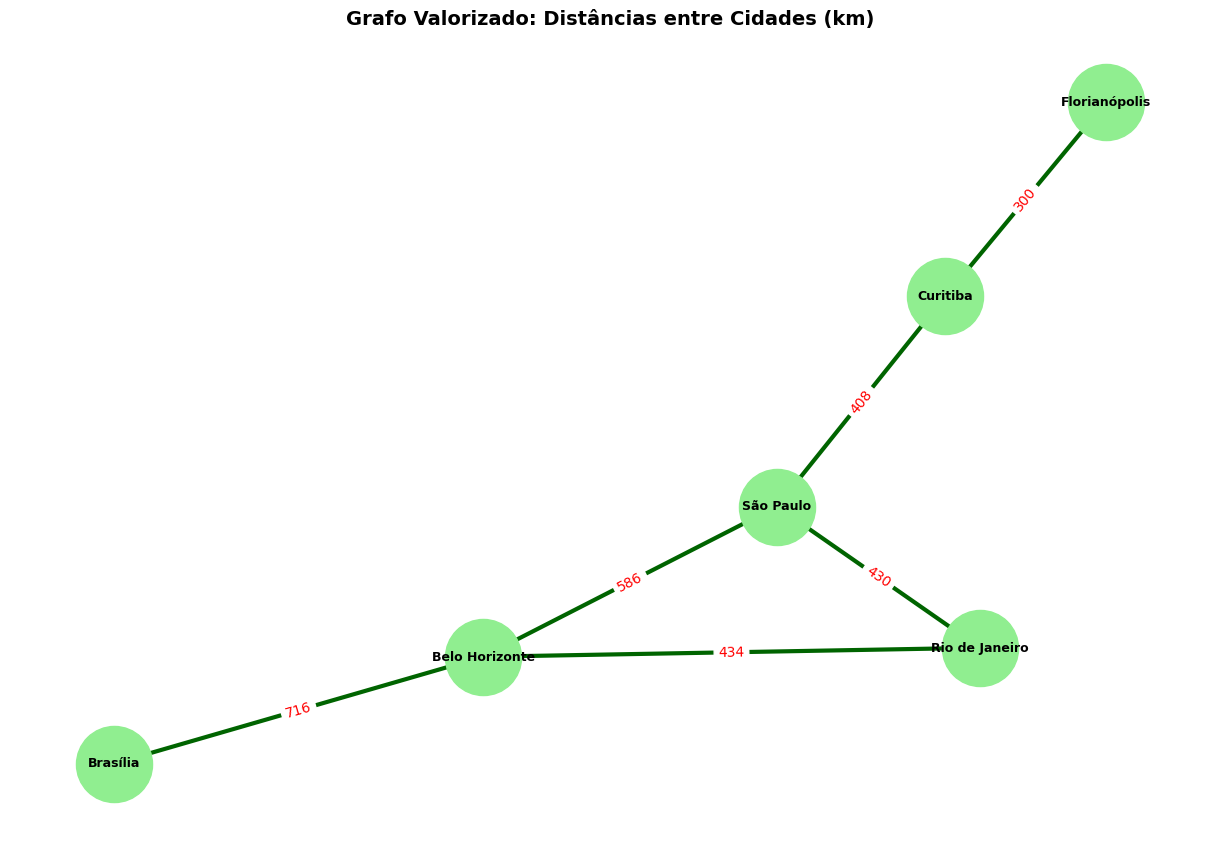

Distâncias:
São Paulo ↔ Rio de Janeiro: 430 km
São Paulo ↔ Belo Horizonte: 586 km
Rio de Janeiro ↔ Belo Horizonte: 434 km
Belo Horizonte ↔ Brasília: 716 km
São Paulo ↔ Curitiba: 408 km
Curitiba ↔ Florianópolis: 300 km


In [14]:
# Criando um grafo valorizado (distâncias entre cidades)
G_peso = nx.Graph()

# Adicionando arestas com pesos (distâncias em km)
cidades_distancias = [
    ('São Paulo', 'Rio de Janeiro', 430),
    ('São Paulo', 'Belo Horizonte', 586),
    ('Rio de Janeiro', 'Belo Horizonte', 434),
    ('Belo Horizonte', 'Brasília', 716),
    ('São Paulo', 'Curitiba', 408),
    ('Curitiba', 'Florianópolis', 300)
]

for cidade1, cidade2, distancia in cidades_distancias:
    G_peso.add_edge(cidade1, cidade2, weight=distancia)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_peso, seed=42, k=2)

# Desenhando o grafo
nx.draw(G_peso, pos,
        with_labels=True,
        node_color='lightgreen',
        node_size=3000,
        font_size=9,
        font_weight='bold',
        edge_color='darkgreen',
        width=3)

# Desenhando os pesos nas arestas
edge_labels = nx.get_edge_attributes(G_peso, 'weight')
nx.draw_networkx_edge_labels(G_peso, pos, edge_labels, font_size=10, font_color='red')

plt.title('Grafo Valorizado: Distâncias entre Cidades (km)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Distâncias:")
for cidade1, cidade2, distancia in cidades_distancias:
    print(f"{cidade1} ↔ {cidade2}: {distancia} km")

In [15]:
# Encontrando o caminho mais curto (algoritmo de Dijkstra)
origem = 'São Paulo'
destino = 'Brasília'

try:
    caminho = nx.shortest_path(G_peso, origem, destino, weight='weight')
    distancia_total = nx.shortest_path_length(G_peso, origem, destino, weight='weight')
    
    print(f"\n🚗 Caminho mais curto de {origem} para {destino}:")
    print(f"Rota: {' → '.join(caminho)}")
    print(f"Distância total: {distancia_total} km")
except nx.NetworkXNoPath:
    print(f"Não há caminho entre {origem} e {destino}")


🚗 Caminho mais curto de São Paulo para Brasília:
Rota: São Paulo → Belo Horizonte → Brasília
Distância total: 1302 km


---

## 5. Grafo Planar

### 📚 Definição:

Um **grafo planar** é um grafo que pode ser desenhado no plano de tal forma que **nenhuma aresta se cruza** (exceto nos vértices).

**Aplicações:**
- Placas de circuito impresso (PCB)
- Mapas geográficos
- Redes de distribuição

### Teorema de Kuratowski:
- $K_5$ (grafo completo com 5 vértices) **não é planar**
- $K_{3,3}$ (grafo bipartido completo) **não é planar**

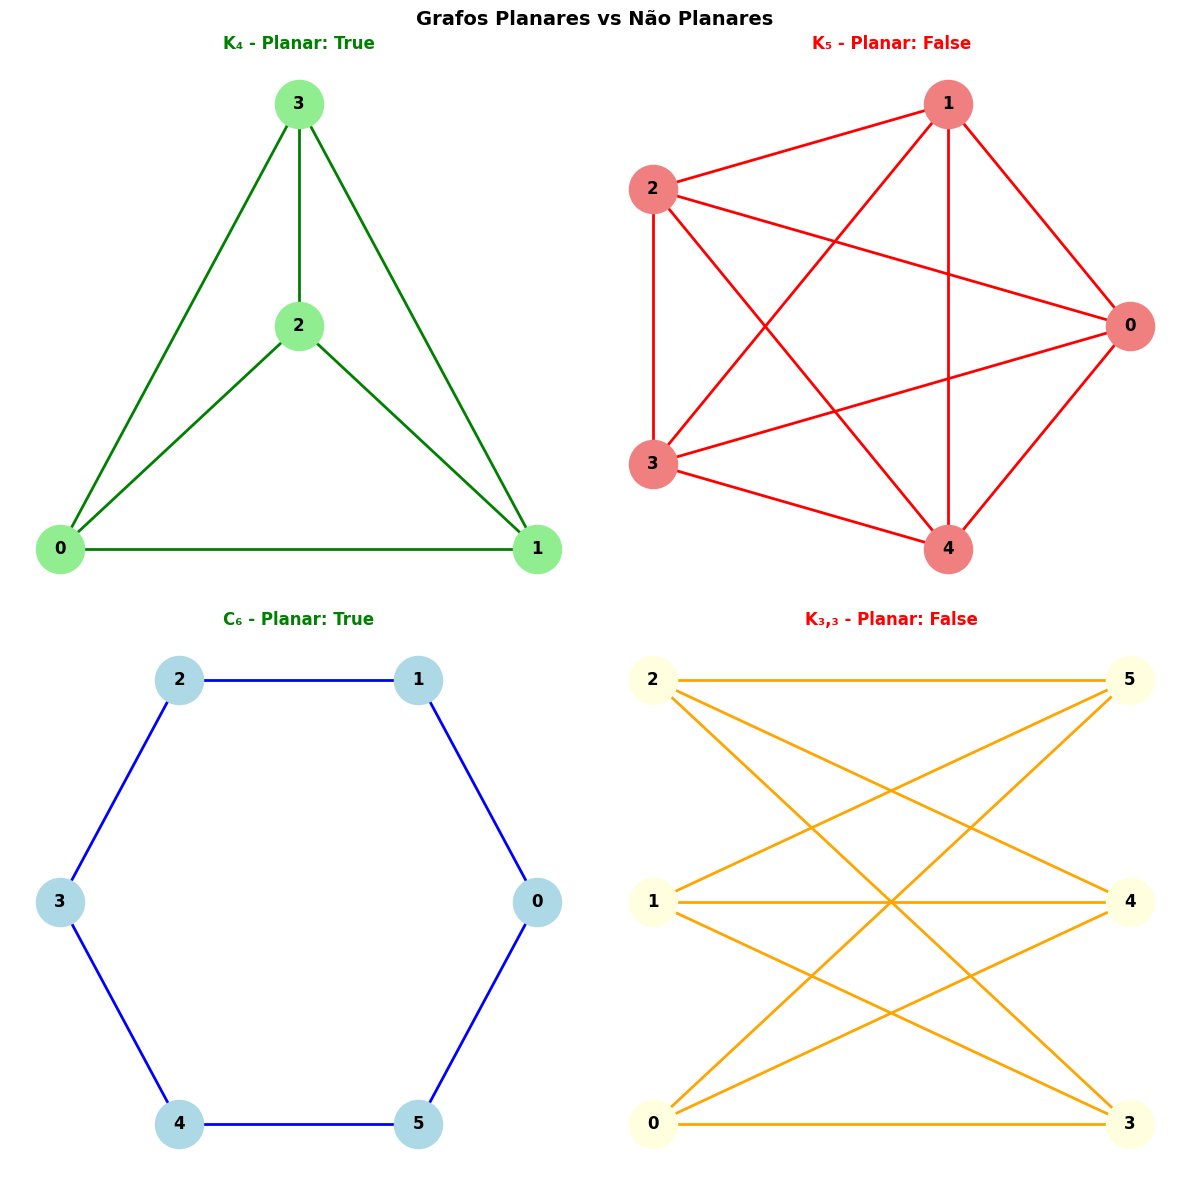

✅ Grafos PLANARES: K₄, C₆
❌ Grafos NÃO PLANARES: K₅, K₃,₃


In [16]:
# Exemplos de grafos planares e não planares
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

# 1. K4 - Planar
K4 = nx.complete_graph(4)
eh_planar_K4 = nx.check_planarity(K4)[0]
nx.draw(K4, nx.planar_layout(K4), ax=axes[0],
        with_labels=True, node_color='lightgreen', node_size=1200,
        font_weight='bold', edge_color='green', width=2)
axes[0].set_title(f'K₄ - Planar: {eh_planar_K4}', fontweight='bold', color='green')
axes[0].axis('off')

# 2. K5 - Não Planar
K5 = nx.complete_graph(5)
eh_planar_K5 = nx.check_planarity(K5)[0]
nx.draw(K5, nx.circular_layout(K5), ax=axes[1],
        with_labels=True, node_color='lightcoral', node_size=1200,
        font_weight='bold', edge_color='red', width=2)
axes[1].set_title(f'K₅ - Planar: {eh_planar_K5}', fontweight='bold', color='red')
axes[1].axis('off')

# 3. C6 - Planar
C6 = nx.cycle_graph(6)
eh_planar_C6 = nx.check_planarity(C6)[0]
nx.draw(C6, nx.circular_layout(C6), ax=axes[2],
        with_labels=True, node_color='lightblue', node_size=1200,
        font_weight='bold', edge_color='blue', width=2)
axes[2].set_title(f'C₆ - Planar: {eh_planar_C6}', fontweight='bold', color='green')
axes[2].axis('off')

# 4. K_{3,3} - Não Planar
K33 = nx.complete_bipartite_graph(3, 3)
eh_planar_K33 = nx.check_planarity(K33)[0]
nx.draw(K33, nx.bipartite_layout(K33, [0,1,2]), ax=axes[3],
        with_labels=True, node_color='lightyellow', node_size=1200,
        font_weight='bold', edge_color='orange', width=2)
axes[3].set_title(f'K₃,₃ - Planar: {eh_planar_K33}', fontweight='bold', color='red')
axes[3].axis('off')

plt.suptitle('Grafos Planares vs Não Planares', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✅ Grafos PLANARES: K₄, C₆")
print("❌ Grafos NÃO PLANARES: K₅, K₃,₃")

---

## 6. Subgrafos

### 📚 Definição:

Um grafo $H = (V', E')$ é um **subgrafo** de $G = (V, E)$ se:
1. $V' \subseteq V$ (vértices de $H$ estão em $G$)
2. $E' \subseteq E$ (arestas de $H$ estão em $G$)
3. Cada aresta de $H$ tem os mesmos nós terminais em $G$

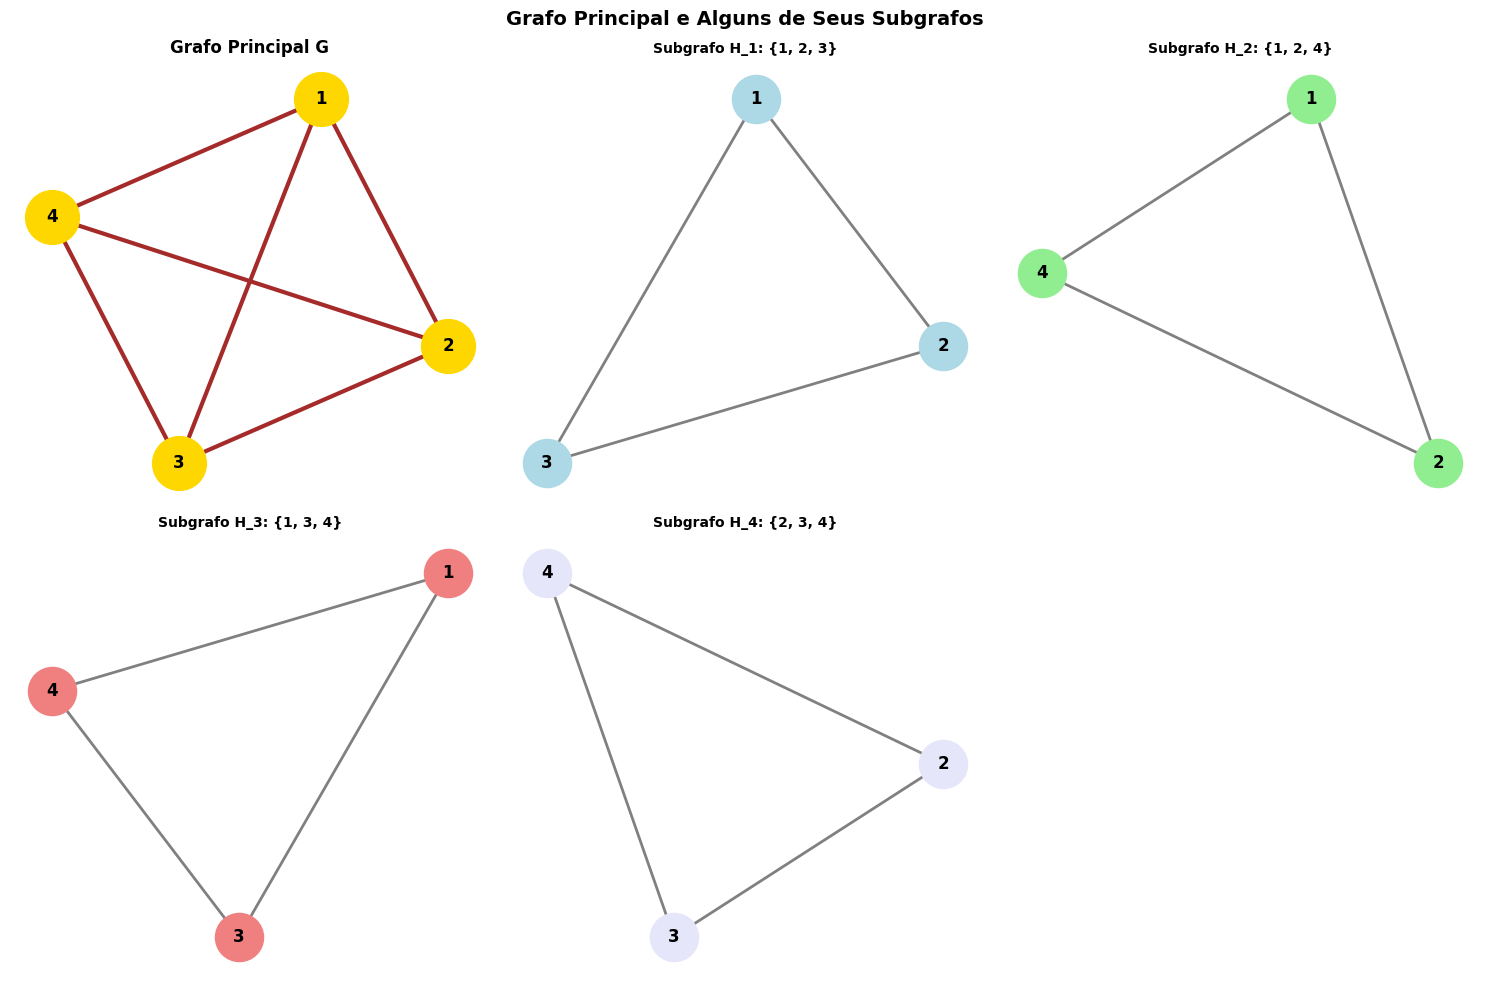

Grafo principal G tem 4 vértices e 6 arestas

Foram gerados 4 subgrafos com 3 vértices


In [17]:
# Criando um grafo e seus subgrafos
G_principal = nx.Graph()
G_principal.add_edges_from([
    (1, 2), (1, 3), (1, 4),
    (2, 3), (2, 4),
    (3, 4)
])

# Gerando todos os subgrafos com 3 vértices
from itertools import combinations

vertices_principais = list(G_principal.nodes())
subgrafos_3v = []

for combo in combinations(vertices_principais, 3):
    subg = G_principal.subgraph(combo).copy()
    if subg.number_of_edges() > 0:  # Apenas subgrafos com arestas
        subgrafos_3v.append(subg)

# Visualização
fig = plt.figure(figsize=(15, 10))

# Grafo principal
ax_main = plt.subplot(2, 3, 1)
pos_main = nx.spring_layout(G_principal, seed=42)
nx.draw(G_principal, pos_main, ax=ax_main,
        with_labels=True, node_color='gold', node_size=1500,
        font_weight='bold', edge_color='brown', width=3)
ax_main.set_title('Grafo Principal G', fontweight='bold', fontsize=12)
ax_main.axis('off')

# Subgrafos
cores_sub = ['lightblue', 'lightgreen', 'lightcoral', 'lavender']
for i, subg in enumerate(subgrafos_3v[:4]):  # Mostra 4 subgrafos
    ax = plt.subplot(2, 3, i + 2)
    pos_sub = {n: pos_main[n] for n in subg.nodes()}
    nx.draw(subg, pos_sub, ax=ax,
            with_labels=True, node_color=cores_sub[i], node_size=1200,
            font_weight='bold', edge_color='gray', width=2)
    vertices_str = '{' + ', '.join(map(str, subg.nodes())) + '}'
    ax.set_title(f'Subgrafo H_{i+1}: {vertices_str}', fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('Grafo Principal e Alguns de Seus Subgrafos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Grafo principal G tem {G_principal.number_of_nodes()} vértices e {G_principal.number_of_edges()} arestas")
print(f"\nForam gerados {len(subgrafos_3v)} subgrafos com 3 vértices")

---

## 7. Exercícios Práticos

🎯 EXERCÍCIO: Analise os grafos e responda



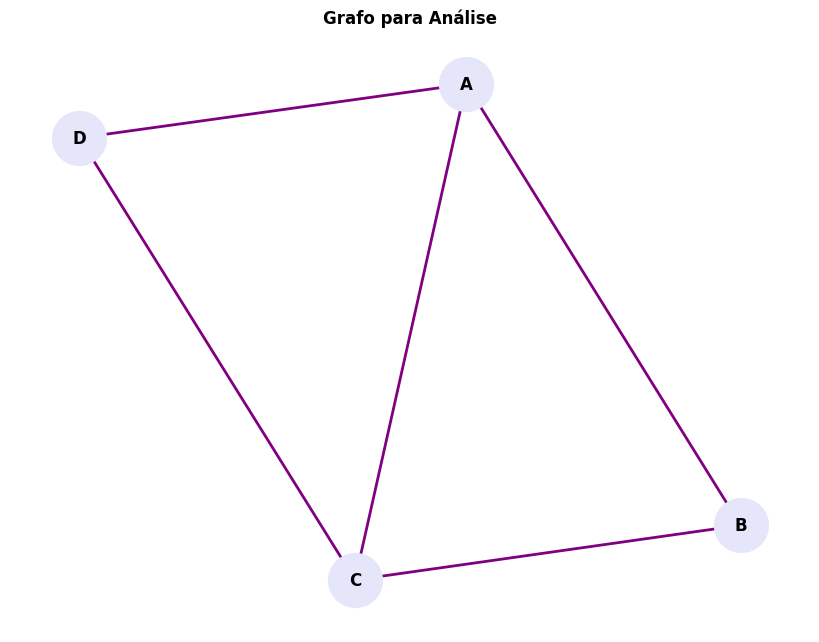

Perguntas:
1. Este grafo é bipartido?
2. Este grafo é planar?
3. Este grafo é completo?
4. Quantos subgrafos com 3 vértices ele possui?

RESPOSTAS:
1. Bipartido: False
2. Planar: True
3. Completo: False
4. Subgrafos possíveis com 3 vértices: 4 (C(4,3))


In [18]:
# Exercício: Verificar propriedades de grafos
print("🎯 EXERCÍCIO: Analise os grafos e responda\n")

# Criando um grafo para análise
G_teste = nx.Graph()
G_teste.add_edges_from([
    ('A', 'B'), ('B', 'C'), ('C', 'D'), 
    ('D', 'A'), ('A', 'C')
])

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_teste, seed=42)
nx.draw(G_teste, pos,
        with_labels=True, node_color='lavender', node_size=1500,
        font_weight='bold', edge_color='purple', width=2)
plt.title('Grafo para Análise', fontweight='bold')
plt.axis('off')
plt.show()

# Perguntas e respostas
print("Perguntas:")
print("1. Este grafo é bipartido?")
print("2. Este grafo é planar?")
print("3. Este grafo é completo?")
print("4. Quantos subgrafos com 3 vértices ele possui?")

print("\n" + "="*50)
print("RESPOSTAS:")
print("="*50)

eh_bip = nx.is_bipartite(G_teste)
print(f"1. Bipartido: {eh_bip}")

eh_plan = nx.check_planarity(G_teste)[0]
print(f"2. Planar: {eh_plan}")

n = G_teste.number_of_nodes()
m = G_teste.number_of_edges()
eh_compl = (m == n * (n - 1) // 2)
print(f"3. Completo: {eh_compl}")

num_subgrafos = len(list(combinations(G_teste.nodes(), 3)))
print(f"4. Subgrafos possíveis com 3 vértices: {num_subgrafos} (C(4,3))")

---

## 📌 Resumo

Neste notebook, exploramos grafos especiais:

| Tipo | Características | Aplicações |
|------|----------------|------------|
| **Bipartido** | Vértices em 2 conjuntos, arestas só entre conjuntos | Matching, redes sociais |
| **Bipartido Completo** $K_{m,n}$ | Todos os pares conectados | Análise combinatória |
| **Multigrafo** | Permite arestas paralelas | Redes de transporte |
| **Valorizado** | Arestas com pesos | Distâncias, custos |
| **Planar** | Pode ser desenhado sem cruzamentos | Circuitos, mapas |
| **Subgrafo** | Parte de outro grafo | Análise estrutural |

### 🎯 Próximo notebook:
**05_grau_teoremas.ipynb** - Grau de vértices, Teorema do Aperto de Mãos e grafos regulares